In [2]:
!pip install -q datasets[audio] soundfile librosa
!pip install -q transformers evaluate jiwer accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 42.9 MB/s eta 0:00:0000:0100:01


## Імпорт бібліотек

In [6]:
import torch
import torch.nn as nn
import pytorch_lightning as pl
from transformers import WhisperForConditionalGeneration, WhisperProcessor
from torchmetrics.text import WordErrorRate, CharErrorRate
import datasets
from datasets import load_dataset
from IPython.display import Audio, display
import matplotlib.pyplot as plt
import pprint
from pytorch_lightning.callbacks import ModelCheckpoint, LearningRateMonitor
import pandas as pd
import numpy as np

## 1. Обрати доцільний притрейн Whisper з huggingface

In [7]:
model_id = "openai/whisper-small"
# Завантажуємо процесор (токенізатор + feature extractor)
# Вказуємо мову та задачу одразу, щоб налаштувати токенізатор
processor = WhisperProcessor.from_pretrained(model_id, language="ukrainian", task="transcribe")
# Завантажуємо саму модель
model = WhisperForConditionalGeneration.from_pretrained(model_id)
# Вказуємо моделі дефолтні параметри для української мови
model.config.forced_decoder_ids = processor.get_decoder_prompt_ids(language="ukrainian", task="transcribe")
model.config.suppress_tokens = [] # дозволяємо моделі генерувати всі токени, очищаємо список заборонених токенів

preprocessor_config.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/967M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

generation_config.json: 0.00B [00:00, ?B/s]

## 2. Імплементувати логіку тренування використовуючи Pytorch Lightning

In [8]:
class WhisperSystem(pl.LightningModule):
    def __init__(self, model_id="openai/whisper-small", lr=1e-6):
        super().__init__()
        # Завантажуємо модель та процесор
        self.model = WhisperForConditionalGeneration.from_pretrained(model_id)
        self.processor = WhisperProcessor.from_pretrained(
            model_id, 
            language="ukrainian", 
            task="transcribe"
        )
        
        # дозволяємо моделі генерувати всі токени, очищаємо список заборонених токенів
        model.config.suppress_tokens = []
        
        # Конфігурація для генерації (щоб завжди була UA)
        self.gen_config = self.model.generation_config
        self.gen_config.update(
            language="ukrainian",
            task="transcribe",
            num_beams=1, # Для швидкості валідації ставимо 1, для тесту поставимо 5
            forced_decoder_ids=self.processor.get_decoder_prompt_ids(language="ukrainian", task="transcribe")
        )

        self.lr = lr
        self.wer_metric = WordErrorRate()
        self.cer_metric = CharErrorRate()

    def forward(self, input_features):
        # Використовується для інференсу (простого передбачення)
        return self.model.generate(input_features, generation_config=self.gen_config)

    def training_step(self, batch, batch_idx):
        # Teacher Forcing: подаємо правильні відповіді (labels) в модель
        input_features = batch["input_features"]
        labels = batch["labels"]

        outputs = self.model(input_features=input_features, labels=labels)
        loss = outputs.loss

        self.log("train_loss", loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        input_features = batch["input_features"]
        labels = batch["labels"]

        # Генеруємо текст (тут модель сама "думає", без підказок)
        predicted_ids = self.model.generate(input_features, generation_config=self.gen_config)
        
        # Декодуємо ID токенів у звичайний текст
        # [! важливе зауваження: міняємо -100 назад на padding_token_id для декодера]
        labels[labels == -100] = self.processor.tokenizer.pad_token_id
        
        pred_str = self.processor.batch_decode(predicted_ids, skip_special_tokens=True)
        label_str = self.processor.batch_decode(labels, skip_special_tokens=True)

        wer = self.wer_metric(pred_str, label_str)
        cer = self.cer_metric(pred_str, label_str)

        self.log("val_wer", wer, prog_bar=True)
        self.log("val_cer", cer, prog_bar=True)
        
        return wer

    def configure_optimizers(self):
        # Використовуємо AdamW для стабільного донавчання
        optimizer = torch.optim.AdamW(self.parameters(), lr=self.lr, weight_decay=0.01)
        # Можна додати Scheduler для поступового зниження LR
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.1)
        return [optimizer], [scheduler]

## 3. Донавчіть модель Whisper на частині датасету Toronto.

Кількість записів: 5227
Стовпці: ['audio', 'transcription', 'transcription_stressed', 'duration']

Структура (Features):
{'audio': Audio(sampling_rate=16000,
                decode=True,
                num_channels=None,
                stream_index=None),
 'duration': Value('float64'),
 'transcription': Value('string'),
 'transcription_stressed': Value('string')}

--- Аналіз найдовшого запису ---
Найдовше аудіо: 11.34 сек.
Індекс запису: 154
Текст: Ви були хорі, любий друже, а хороба знесилює мозок, отже, я вибачаю вам.



Перший запис (приклад):
{'audio': <datasets.features._torchcodec.AudioDecoder object at 0x7a68203ee3c0>,
 'duration': 8.1,
 'transcription': '— Не питайте мене.',
 'transcription_stressed': '— Не пита́йте мене́.'}


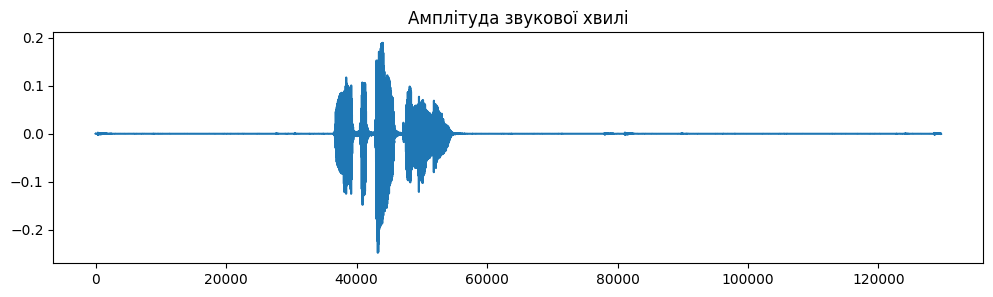

In [11]:
dataset = load_dataset("speech-uk/opentts-tetiana", split="train")
dataset = dataset.cast_column("audio", datasets.Audio(sampling_rate=16000))
print(f"Кількість записів: {len(dataset)}")
print(f"Стовпці: {dataset.column_names}")
print("\nСтруктура (Features):")
pprint.pprint(dataset.features)
durations = dataset["duration"]
max_val = max(durations)
max_idx = int(np.argmax(durations))
print(f"\n--- Аналіз найдовшого запису ---")
print(f"Найдовше аудіо: {max_val:.2f} сек.")
print(f"Індекс запису: {max_idx}")
print(f"Текст: {dataset[max_idx]['transcription']}")
longest_sample = dataset[max_idx]
display(Audio(longest_sample["audio"]["array"], rate=longest_sample["audio"]["sampling_rate"]))
print("\nПерший запис (приклад):")
sample = dataset[0]
pprint.pprint(sample)
display(Audio(sample["audio"]["array"], rate=sample["audio"]["sampling_rate"]))
plt.figure(figsize=(12, 3))
plt.plot(sample["audio"]["array"])
plt.title("Амплітуда звукової хвилі")
plt.show()

In [17]:
# Додаємо стовпець 'id' на основі індексу рядка
dataset = dataset.map(lambda x, idx: {"id": f"toronto_{idx}"}, with_indices=True)
print(f"Нові стовпці: {dataset.column_names}") 
dataset = dataset.select_columns(['audio', 'transcription', 'id'])
print(f"Залишилися стовпці: {dataset.column_names}")

Map:   0%|          | 0/5227 [00:00<?, ? examples/s]

Нові стовпці: ['audio', 'transcription', 'transcription_stressed', 'duration', 'id']
Залишилися стовпці: ['audio', 'transcription', 'id']


In [14]:
# Список файлів для ТЕСТУВАННЯ (їх не можна бачити при навчанні)
test_lines = [
    'toronto_27', 'toronto_46', 'toronto_42', 'toronto_37', 'toronto_89', 
    'toronto_43', 'toronto_157', 'toronto_9', 'toronto_156', 'toronto_7', 
    'toronto_123', 'toronto_54', 'toronto_67', 'toronto_62', 'toronto_81', 
    'toronto_134', 'toronto_148', 'toronto_21', 'toronto_135', 'toronto_166', 
    'toronto_58'
]

print(f"{'ID':<15} | {'Реальний текст'}")
print("-" * 50)
for t_id in test_lines:
    try:
        idx = int(t_id.split('_')[-1]) 
        actual_text = dataset[idx]["transcription"]
        print(f"{t_id:<15} | {actual_text}")
    except (IndexError, ValueError):
        print(f"{t_id:<15} | Помилка: індекс не відповідає довжині датасету")

test_dataset = dataset.filter(lambda x: x["id"] in test_lines)
# Решта йде на навчання та валідацію
train_val_raw = dataset.filter(lambda x: x["id"] not in test_lines)
#  Робимо фінальний спліт (наприклад, 10% на валідацію)
train_val_split = train_val_raw.train_test_split(test_size=0.1)
train_dataset = train_val_split["train"]
val_dataset = train_val_split["test"]

print(f"Train size: {len(train_dataset)}")
print(f"Val size: {len(val_dataset)}")
print(f"Test size: {len(test_dataset)}")

Filter:   0%|          | 0/5227 [00:00<?, ? examples/s]

Filter:   0%|          | 0/5227 [00:00<?, ? examples/s]

Train size: 4685
Val size: 521
Test size: 21


In [31]:
def prepare_dataset(batch):
    # Звук -> Спектрограма (input_features)
    audio = batch["audio"]
    batch["input_features"] = processor.feature_extractor(
        audio["array"], sampling_rate=audio["sampling_rate"]
    ).input_features[0]
    # Текст -> Токени (labels)
    batch["labels"] = processor.tokenizer(batch["transcription"]).input_ids
    return batch

try:
    test_ds = train_dataset.select(range(10)).map(prepare_dataset)
    print("Done")
    print("Size input_features:", len(test_ds[0]["input_features"]))
except Exception as e:
    print(f"Помилка: {e}")

Done
Size input_features: 80


In [34]:
train_dataset = train_dataset.map(prepare_dataset, num_proc=None)
val_dataset = val_dataset.map(prepare_dataset, num_proc=None)

Map:   0%|          | 0/4685 [00:00<?, ? examples/s]

Map:   0%|          | 0/521 [00:00<?, ? examples/s]

In [35]:
from dataclasses import dataclass
from typing import Any, Dict, List, Union

@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: Any
    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        input_features = [{"input_features": f["input_features"]} for f in features]
        batch = self.processor.feature_extractor.pad(input_features, return_tensors="pt")

        label_features = [{"input_ids": f["labels"]} for f in features]
        labels_batch = self.processor.tokenizer.pad(label_features, return_tensors="pt")

        # Замінюємо падінг на -100, щоб модель його ігнорувала в Loss
        labels = labels_batch["input_ids"].masked_fill(labels_batch.attention_mask.ne(1), -100)
        batch["labels"] = labels
        return batch

data_collator = DataCollatorSpeechSeq2SeqWithPadding(processor=processor)

from torch.utils.data import DataLoader
train_loader = DataLoader(train_dataset, batch_size=4, collate_fn=data_collator, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, collate_fn=data_collator)

In [36]:
model_lightning = WhisperSystem(lr=1e-5)

# Налаштування чекпоінтів (зберігаємо найкращу модель по WER)
checkpoint_callback = ModelCheckpoint(
    monitor="val_wer",
    mode="min",
    save_top_k=1,
    filename="whisper-best"
)

trainer = pl.Trainer(
    max_epochs=1,
    accelerator="gpu",
    devices=1,
    precision="16-mixed",    # FP16 для економії VRAM
    callbacks=[checkpoint_callback, LearningRateMonitor(logging_interval="step")],
    val_check_interval=0.5   # Перевіряти якість двічі за епоху
)

trainer.fit(model_lightning, train_loader, val_loader)

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
2026-04-23 16:31:48.195673: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776961908.574497      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776961908.691115      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776961909.621388      55 computation_placer.cc:177] computation placer

┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model      │ WhisperForConditionalGeneration │  241 M │ eval  │     0 │
│ 1 │ wer_metric │ WordErrorRate                   │      0 │ train │     0 │
│ 2 │ cer_metric │ CharErrorRate                   │      0 │ train │     0 │
└───┴────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 241 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 241 M                                                                                                
Total estimated model params size (MB): 966                                                                        
Modules in train mode: 2                                                                                           
Modules in eval mode: 350                                                                                          
Total FLOPs: 0

Output()

...

Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, 

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 
'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py:534: Found 350 module(s) in eval mode 
at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can 
ignore this warning.

`Trainer.fit` stopped: `max_epochs=1` reached.


## 4. Не використовуйте наступну частину датасету Toronto ні для навчання, ні для валідації. Використовуйте її лише для тестування вашої фінальної моделі. Використовуйте метрики CER та WER (а також інші, за бажанням).

In [37]:
# Створюємо DataLoader для тесту
# batch_size=1, щоб ми могли детально проаналізувати кожен приклад
test_loader = DataLoader(
    test_dataset.map(prepare_dataset), 
    batch_size=1, 
    collate_fn=data_collator
)

Map:   0%|          | 0/21 [00:00<?, ? examples/s]

In [38]:
# Завантажуємо найкращу модель (якщо тренування закінчилося)
# model_lightning = WhisperSystem.load_from_checkpoint(checkpoint_callback.best_model_path)

# Перемикаємо на якісне декодування
model_lightning.gen_config.update(num_beams=5) 
model_lightning.eval() # Режим оцінки

WhisperSystem(
  (model): WhisperForConditionalGeneration(
    (model): WhisperModel(
      (encoder): WhisperEncoder(
        (conv1): Conv1d(80, 768, kernel_size=(3,), stride=(1,), padding=(1,))
        (conv2): Conv1d(768, 768, kernel_size=(3,), stride=(2,), padding=(1,))
        (embed_positions): Embedding(1500, 768)
        (layers): ModuleList(
          (0-11): 12 x WhisperEncoderLayer(
            (self_attn): WhisperAttention(
              (k_proj): Linear(in_features=768, out_features=768, bias=False)
              (v_proj): Linear(in_features=768, out_features=768, bias=True)
              (q_proj): Linear(in_features=768, out_features=768, bias=True)
              (out_proj): Linear(in_features=768, out_features=768, bias=True)
            )
            (self_attn_layer_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
            (activation_fn): GELUActivation()
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            (fc2): Linear

In [40]:
results = []
model_lightning.to("cuda") # Переносимо на GPU

print("--- Починаємо фінальне тестування на 21 фрагменті ---")

with torch.no_grad():
    for i, batch in enumerate(test_loader):
        # Запобіжник: якщо в лоадері більше записів, ніж у списку ID
        if i >= len(test_lines):
            break
        
        input_features = batch["input_features"].to("cuda")
        labels = batch["labels"].to("cuda")

        # Генеруємо текст
        predicted_ids = model_lightning.model.generate(
            input_features, 
            generation_config=model_lightning.gen_config
        )
        
        # Декодуємо
        transcription = model_lightning.processor.batch_decode(predicted_ids, skip_special_tokens=True)[0]
        
        # Декодуємо оригінал (прибираємо -100)
        labels[labels == -100] = model_lightning.processor.tokenizer.pad_token_id
        reference = model_lightning.processor.batch_decode(labels, skip_special_tokens=True)[0]

        # Рахуємо метрики для конкретного рядка
        row_wer = model_lightning.wer_metric(transcription, reference)
        row_cer = model_lightning.cer_metric(transcription, reference)

        results.append({
            "ID": test_lines[i],
            "Reference": reference,
            "Predicted": transcription,
            "WER": f"{row_wer:.4f}",
            "CER": f"{row_cer:.4f}"
        })

df_results = pd.DataFrame(results)
display(df_results)

print(f"\nСЕРЕДНІЙ WER: {df_results['WER'].astype(float).mean():.4f}")
print(f"СЕРЕДНІЙ CER: {df_results['CER'].astype(float).mean():.4f}")

--- Починаємо фінальне тестування на 21 фрагменті ---


,ID,Reference,Predicted,WER,CER
0,toronto_27,"— Не можу, — сказав шляхтич.","— Не можу, — сказав шляхтич.",0.0000,0.0000
1,toronto_46,Недалеко треба було й шукати.,Не далеко треба було й шукати.,0.4000,0.0345
2,toronto_42,"Череваниху назвав гетьман, вітаючись, рідною н...","Черевануху назвав гетьман, відтаючись, рідною ...",0.5000,0.0588
3,toronto_37,"Люблю її, живу споминами про неї, і досить мені.","— Люблю її, живу споминами про неї, і досить м...",0.1111,0.0417
4,toronto_89,"На вулиці Генеґо він побачив, як з вулиці Дофі...","На вулиці Генегу він побачив, як звулиці до Фі...",0.3333,0.0909
5,toronto_43,"Леся щебетала, як ластівочка.","Леся ще битала, як ластівочка.",0.5000,0.0690
6,toronto_157,"Виступайте проти мене, дурні ви такі.",Ви ступаєте проти мене! Дурні ви такі!,0.8333,0.1351
7,toronto_9,"Безсумнівно, Фелтон був переможений.","Безсумнівно, Фалтон був переможений.",0.2500,0.0278
8,toronto_156,По цих словах він зирнув на свого приятеля так...,По цих словах він зирнув на свого приятеля так...,0.0000,0.0000
9,toronto_7,"— Я? — запаленівшися, відказав Едмунд.",— Я? — запаленівшися відказав Едмунд.,0.1667,0.0263



СЕРЕДНІЙ WER: 0.1887
СЕРЕДНІЙ CER: 0.0317
